In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

DATA_PATH = r"C:\Users\Andalan\Documents\Lomba\Satria Data 2026 - Belmawa\data\reviews_cleaned_rating_1_2.csv"
OUT_EDA = Path(r"C:\Users\Andalan\Documents\Lomba\Satria Data 2026 - Belmawa\eda")
OUT_EDA.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nKolom:", list(df.columns))
print("\nWilayah:", df['wilayah'].value_counts().to_dict())
df.head(3)

Shape: (8641, 15)

Kolom: ['review_id', 'puskesmas_id', 'puskesmas_name', 'puskesmas_title', 'wilayah', 'rating', 'review_text', 'reviewer_name', 'review_url', 'puskesmas_url', 'source_file', 'text_length', 'is_empty_text', 'is_very_short', 'has_rating']

Wilayah: {'Surabaya': 5750, 'Semarang': 1595, 'Bantul': 1296}


,review_id,puskesmas_id,puskesmas_name,puskesmas_title,wilayah,rating,review_text,reviewer_name,review_url,puskesmas_url,source_file,text_length,is_empty_text,is_very_short,has_rating
0,PKM_BTL_001_R0028_50535ba8,PKM_BTL_001,Bambanglipuro,PUSKESMAS BAMBANGLIPURO,Bantul,1,Pelayanan nya kurang di saat saya memberitau t...,Pitra Rara,https://www.google.com/maps/reviews/data=!4m8!...,https://www.google.com/maps/search/?api=1&quer...,Puskesmas Bambanglipuro.csv,194,False,False,True
1,PKM_BTL_001_R0034_6e9b5809,PKM_BTL_001,Bambanglipuro,PUSKESMAS BAMBANGLIPURO,Bantul,1,Saya beri rating 1 khusus untuk perawat fisiot...,Indriyanto Rochmad,https://www.google.com/maps/reviews/data=!4m8!...,https://www.google.com/maps/search/?api=1&quer...,Puskesmas Bambanglipuro.csv,152,False,False,True
2,PKM_BTL_001_R0036_71016d14,PKM_BTL_001,Bambanglipuro,PUSKESMAS BAMBANGLIPURO,Bantul,1,Perkara nama doang diketawain padahal saya ga ...,Anisatun Nisak,https://www.google.com/maps/reviews/data=!4m8!...,https://www.google.com/maps/search/?api=1&quer...,Puskesmas Bambanglipuro.csv,85,False,False,True


In [11]:
# pip install emoji
import emoji
import re
import pandas as pd

def hanya_emoji(teks):
    t = str(teks).strip()
    if not t:
        return False  # kosong, bukan "emoji saja"
    # buang semua emoji
    tanpa_emoji = emoji.replace_emoji(t, replace="")
    # buang spasi & tanda baca sisa (titik, koma, dll)
    sisa = re.sub(r"[\s\W_]+", "", tanpa_emoji, flags=re.UNICODE)
    # kalau tidak ada huruf/angka tersisa DAN tadi memang ada emoji -> emoji saja
    ada_emoji = emoji.emoji_count(t) > 0
    return ada_emoji and sisa == ""

df["emoji_saja"] = df["review_text"].apply(hanya_emoji)

          count  mean  median   std
wilayah                            
Bantul    10325  4.29     5.0  1.40
Semarang  24513  4.65     5.0  1.04
Surabaya  34193  4.16     5.0  1.55


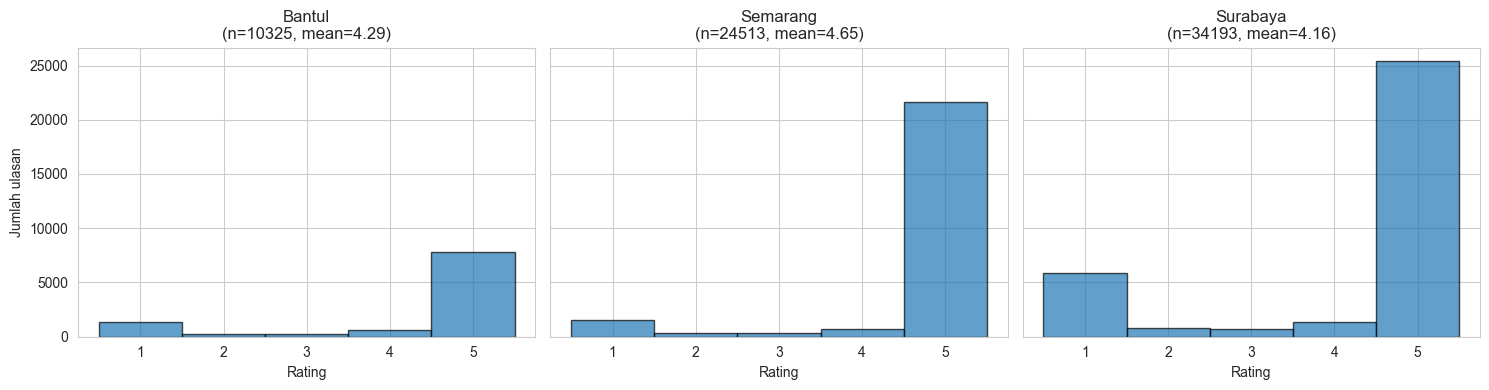


Proporsi rating (%) per wilayah:
rating       1    2    3    4     5
wilayah                            
Bantul    13.0  2.4  2.7  6.2  75.7
Semarang   6.3  1.3  1.3  2.7  88.4
Surabaya  17.3  2.4  2.2  4.0  74.2


In [2]:
# Distribusi rating per wilayah
stats_wil = df.groupby('wilayah')['rating'].agg(['count','mean','median','std']).round(2)
print(stats_wil)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, wil in zip(axes, sorted(df['wilayah'].unique())):
    sub = df[df['wilayah'] == wil]['rating'].dropna()
    ax.hist(sub, bins=[0.5,1.5,2.5,3.5,4.5,5.5], edgecolor='black', alpha=0.7)
    ax.set_title(f"{wil}\n(n={len(sub)}, mean={sub.mean():.2f})")
    ax.set_xlabel("Rating"); ax.set_xticks([1,2,3,4,5])
axes[0].set_ylabel("Jumlah ulasan")
plt.tight_layout()
plt.savefig(OUT_EDA / "rating_distribution_by_wilayah.png", dpi=150, bbox_inches='tight')
plt.show()

# Proporsi tiap rating per wilayah
prop = (df.groupby('wilayah')['rating']
          .value_counts(normalize=True).unstack().round(3) * 100)
print("\nProporsi rating (%) per wilayah:")
print(prop)

In [3]:
# Ranking puskesmas (pakai agregat per puskesmas)
MIN_N = 30

agg = (df.groupby(['puskesmas_id','puskesmas_name','wilayah'])
         .agg(n_reviews=('rating','count'),
              rating_mean=('rating','mean'),
              rating_std=('rating','std'))
         .reset_index())
agg[['rating_mean','rating_std']] = agg[['rating_mean','rating_std']].round(2)

elig = agg[agg['n_reviews'] >= MIN_N].copy()
print(f"Puskesmas lolos threshold n>={MIN_N}: {len(elig)} dari {len(agg)}")

top10  = elig.nlargest(10, 'rating_mean')
bot10  = elig.nsmallest(10, 'rating_mean')
pol10  = elig.nlargest(10, 'rating_std')   # std tertinggi = paling terpolarisasi

print("\n=== TOP 10 ==="); print(top10.to_string(index=False))
print("\n=== BOTTOM 10 ==="); print(bot10.to_string(index=False))
print("\n=== PALING POLARIZED (std tertinggi) ==="); print(pol10.to_string(index=False))

pd.concat([top10.assign(kategori='top'),
           bot10.assign(kategori='bottom'),
           pol10.assign(kategori='polarized')]).to_csv(
           OUT_EDA / "puskesmas_rankings.csv", index=False)

Puskesmas lolos threshold n>=30: 126 dari 127

=== TOP 10 ===
puskesmas_id    puskesmas_name  wilayah  n_reviews  rating_mean  rating_std
 PKM_SMG_003          Bugangan Semarang       1030         4.93        0.46
 PKM_SMG_027          Pegandan Semarang        119         4.88        0.65
 PKM_SMG_033           Srondol Semarang       1686         4.86        0.65
 PKM_SMG_037       Karanganyar Semarang        527         4.84        0.67
 PKM_SMG_021            Miroto Semarang        723         4.80        0.83
 PKM_SMG_030         Purwoyoso Semarang        819         4.79        0.82
 PKM_SMG_018          Mangkang Semarang        225         4.76        0.88
 PKM_SMG_035  Telogosari Kulon Semarang       1955         4.75        0.91
 PKM_SMG_023 Ngemplak Simongan Semarang        477         4.74        0.88
 PKM_SMG_009         Halmahera Semarang        856         4.72        0.93

=== BOTTOM 10 ===
puskesmas_id puskesmas_name  wilayah  n_reviews  rating_mean  rating_std
 PKM_SBY_0

In [4]:
# C3: Ambil sampel ulasan untuk dibaca manual
fokus_ids = pd.concat([top10.head(3), bot10.head(3), pol10.head(3)])['puskesmas_id'].tolist()

# Hanya ulasan dengan teks bermakna (ingat banyak ulasan kosong/super pendek)
bermakna = df[(df['puskesmas_id'].isin(fokus_ids)) &
              (df['review_text'].notna()) &
              (df['review_text'].str.len() >= 40)]

for pid in fokus_ids:
    sub = bermakna[bermakna['puskesmas_id'] == pid]
    nama = sub['puskesmas_name'].iloc[0] if len(sub) else pid
    print(f"\n{'='*70}\n{pid} — {nama}  (tersedia {len(sub)} ulasan bermakna)")
    n_ambil = min(8, len(sub))
    if n_ambil:
        for _, r in sub.sample(n_ambil, random_state=42).iterrows():
            print(f"  [★{r['rating']}] {r['review_text'][:300]}")


PKM_SMG_003 — Bugangan  (tersedia 297 ulasan bermakna)
  [★5] Trimakasih puskesmas bungangan sudah menjadi pertolongan pertama d kala sakit ,proses cepat,dokter dan para staf sangat baik dan ramah
  [★5] Pelayanan di fasilitas farmasi ramah,
Pelayanan memuasakan baik & sesui 🙏🏻
  [★5] Pelayanan cepat, petugas ramah, menjelaskan dengan baik, obat lengkap, jaya terus puskesmas bungangan
  [★5] Pelayanan puskesmas bugangan oke, dan pendaftaran nya cepat
  [★5] Puskesmas dengan fasilitas yang nyaman, petugas kesehatan sangat mengayomi dan ramah. Pelayanan kesehatan cepat😁
  [★5] Pelayanan dokter kepasien alhamdulillah sangat baik..
  [★5] pelayanan di poli gigi sngt ramah, tmptnya bersih dan wangi
  [★5] Pelayanan mantapp, di bantu sampai dapat rujukan ,

PKM_SMG_027 — Pegandan  (tersedia 60 ulasan bermakna)
  [★5] Terimakasih Bu bidan Aria dan bidan Zaki. Sudah menyelenggarakan kelas ibu hamil
  [★5] terimakasih mb aria & mb dewi, sudah mengundang kami.
sehingga kami dapat ilmu, tempat n

In [9]:
# C4: Kata khas rating negatif vs positif (TF-IDF)
# === Stopword + slang Indonesia (lengkap) ===
stop_id = set("""
yang yg di ke dari dan untuk utk dengan dgn dg ini itu ada tidak tdk gak ga gk ngga nggak
enggak engga kaga kagak nggk tak ndak saya saya nya ny juga jg sudah udah udh sdh dah akan
pada aja saja sih ya yaa iya tapi tp namun karena krn kalau kalo klo klu jika bila agar supaya
adalah ialah dengan oleh atas bagi serta atau maupun lalu kemudian terus trus banget bgt bngt
bener banar benar memang emang mmg mang nih neh tuh deh dehh kok kah lah pun per para si sang
ku mu kau kamu aku gue gua gw ane situ situh dia beliau mereka kita kami kalian sob gan bro
sis mas mba mbak bu pak bapak ibu om tante kak kakak adik dek mbah eyang
ada adanya adalah saat ketika waktu wkt selama sambil setelah sebelum sblm sesudah sampe sampai
hingga sehingga jadi jd menjadi bikin buat buatkan kasih kasi ngasih dikasih dapat dpt mendapat
dapet bisa bs dapatkan boleh harus hrs mesti kudu wajib perlu butuh pengen pgn pengin pingin
mau maupun ingin pgin ya ye yo loh lho dong donk doang doank cuma cuman hanya hny kek kayak kaya
kya gini gitu gtu git begini begitu seperti spt sprt seakan seolah macam macem misal misalnya
juga sama sm dengan saling masing per setiap tiap semua smua semuanya seluruh sebagian beberapa
bbrp banyak byk sedikit dikit dgn lebih lbh paling plg sangat sgt amat begitu skali sekali bener
nan se ber ter di ke me pe an kan i nya
puskesmas pkm puskesmasnya puskemas pusekesmas faskes klinik tempat tmpt tempatnya disini sini
sana situ kesini kesana kemari pelayanan pelayanannya pelayananya pelayanan layanan layananya
layanannya servis service pelayan melayani dilayani pasien pasiennya orang org orangnya warga
masyarakat pengunjung antrian antri antre antrean ngantri ngantre poli poliklinik loket
ruang ruangan kamar gedung kantor jam waktu hari jadwal jadwalnya menit detik tahun bulan
minggu pagi siang sore malam subuh dini banget bgt bener jadi
ke nya kan in lah pun ya dong sih deh kok mah toh
""".split())
print(f"Total stopword: {len(stop_id)}")


# Weighted log-odds dengan Dirichlet prior (Monroe et al. 2008)
# Mengukur kata mana yang KHAS untuk tiap grup, bukan sekadar sering.
from sklearn.feature_extraction.text import CountVectorizer

teks = df[(df['review_text'].notna()) & (df['review_text'].str.len() >= 20)].copy()
neg_corpus = teks[teks['rating'].isin([1,2])]['review_text']
pos_corpus = teks[teks['rating'].isin([4,5])]['review_text']
print(f"Negatif (1-2): {len(neg_corpus)} | Positif (4-5): {len(pos_corpus)}")

# Hitung count gabungan; ngram 1-2; buang kata sangat jarang
vec = CountVectorizer(stop_words=list(stop_id), ngram_range=(1,2),
                      min_df=15, max_features=5000)
X = vec.fit_transform(pd.concat([neg_corpus, pos_corpus]))
vocab = np.array(vec.get_feature_names_out())

n_neg = len(neg_corpus)
counts_neg = np.asarray(X[:n_neg].sum(axis=0)).ravel()
counts_pos = np.asarray(X[n_neg:].sum(axis=0)).ravel()

# Prior informatif = frekuensi keseluruhan (alpha), skala a0
alpha = counts_neg + counts_pos
a0 = alpha.sum()
y_neg, y_pos = counts_neg.sum(), counts_pos.sum()

# log-odds-ratio dengan prior, lalu z-score (Monroe et al.)
def logodds(cnt, total, alpha, a0):
    return np.log((cnt + alpha) / (total + a0 - cnt - alpha))

delta = logodds(counts_pos, y_pos, alpha, a0) - logodds(counts_neg, y_neg, alpha, a0)
var = 1.0/(counts_neg + alpha) + 1.0/(counts_pos + alpha)
z = delta / np.sqrt(var)

res = (pd.DataFrame({'term': vocab, 'z_score': z.round(2),
                     'n_neg': counts_neg, 'n_pos': counts_pos})
         .sort_values('z_score'))

print("\n=== PALING KHAS NEGATIF (z paling negatif) ===")
print(res.head(25).to_string(index=False))
print("\n=== PALING KHAS POSITIF (z paling positif) ===")
print(res.tail(25).iloc[::-1].to_string(index=False))

res.to_csv(OUT_EDA / "keyword_signals.csv", index=False)

Total stopword: 310
Negatif (1-2): 8641 | Positif (4-5): 34677

=== PALING KHAS NEGATIF (z paling negatif) ===
     term  z_score  n_neg  n_pos
    malah   -28.49   1845     70
    buruk   -23.33   1217     35
   tolong   -23.05   1419    161
  padahal   -22.14   1319    154
    sakit   -20.44   1863    645
   kurang   -20.11   1495    393
    minta   -19.65   1261    260
   nunggu   -19.56   1293    287
      apa   -19.28   1465    427
   bilang   -18.39    826     58
  disuruh   -17.24    708     41
     lagi   -17.14   2011   1055
    surat   -16.75   1171    370
    suruh   -16.34    642     40
     lama   -16.22   1907   1043
   kecewa   -15.86    616     44
  katanya   -15.83    607     40
      tau   -15.75    788    152
    kerja   -14.29    691    153
   datang   -14.12   1240    601
    bukan   -14.06    753    207
dipanggil   -13.64    607    124
    masih   -13.35    947    397
   kenapa   -13.27    450     41
    bayar   -13.24    599    135

=== PALING KHAS POSITIF (z pal

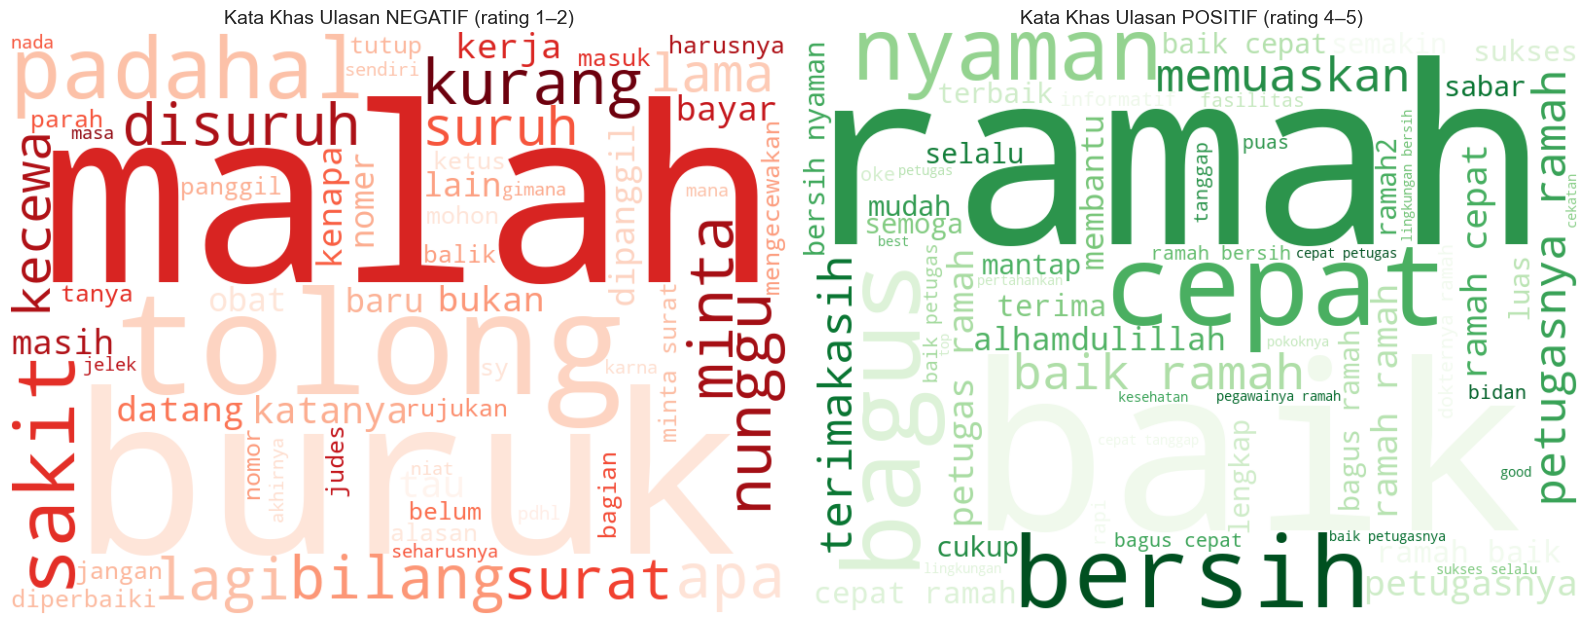

In [ ]:
# === Word cloud dari hasil log-odds ===
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Bobot = |z_score|. Ambil hanya kata yang condong ke grupnya.
neg_w = (res[res['z_score'] < 0]
         .assign(weight=lambda d: d['z_score'].abs())
         .set_index('term')['weight'].to_dict())
pos_w = (res[res['z_score'] > 0]
         .assign(weight=lambda d: d['z_score'])
         .set_index('term')['weight'].to_dict())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_neg = WordCloud(width=800, height=600, background_color='white',
                   colormap='Reds', prefer_horizontal=0.9,
                   max_words=60).generate_from_frequencies(neg_w)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title("Kata Khas Ulasan NEGATIF (rating 1–2)", fontsize=14)
axes[0].axis('off')

wc_pos = WordCloud(width=800, height=600, background_color='white',
                   colormap='Greens', prefer_horizontal=0.9,
                   max_words=60).generate_from_frequencies(pos_w)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title("Kata Khas Ulasan POSITIF (rating 4–5)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUT_EDA / "wordcloud_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

Spearman rho = 0.318, p = 0.0003  (n=127 puskesmas)


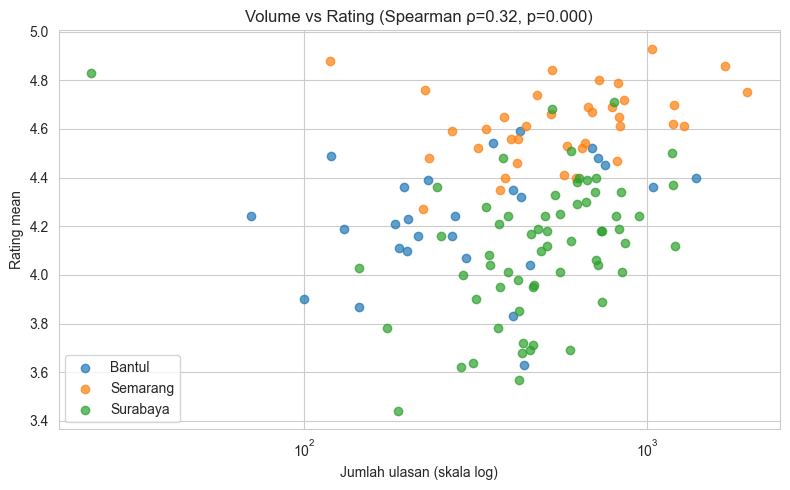

In [6]:
# Hubungan volume ulasan vs rating
from scipy.stats import spearmanr

rho, p = spearmanr(agg['n_reviews'], agg['rating_mean'])
print(f"Spearman rho = {rho:.3f}, p = {p:.4f}  (n={len(agg)} puskesmas)")

plt.figure(figsize=(8,5))
for wil, c in zip(sorted(agg['wilayah'].unique()), ['#1f77b4','#ff7f0e','#2ca02c']):
    s = agg[agg['wilayah']==wil]
    plt.scatter(s['n_reviews'], s['rating_mean'], label=wil, alpha=0.7, color=c)
plt.xscale('log')  # n_reviews sangat skewed (24 s/d 1955)
plt.xlabel("Jumlah ulasan (skala log)"); plt.ylabel("Rating mean")
plt.title(f"Volume vs Rating (Spearman ρ={rho:.2f}, p={p:.3f})")
plt.legend(); plt.tight_layout()
plt.savefig(OUT_EDA / "volume_vs_rating.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cek korelasi volume vs rating DI DALAM tiap wilayah (kontrol confound wilayah)
from scipy.stats import spearmanr

print("=== Spearman per wilayah ===")
for wil in sorted(agg['wilayah'].unique()):
    s = agg[agg['wilayah'] == wil]
    rho_w, p_w = spearmanr(s['n_reviews'], s['rating_mean'])
    print(f"{wil:10s}: rho = {rho_w:+.3f}, p = {p_w:.4f}  (n={len(s)})")

rho_all, p_all = spearmanr(agg['n_reviews'], agg['rating_mean'])
print(f"{'GABUNGAN':10s}: rho = {rho_all:+.3f}, p = {p_all:.4f}  (n={len(agg)})")

=== Spearman per wilayah ===
Bantul    : rho = +0.323, p = 0.1001  (n=27)
Semarang  : rho = +0.400, p = 0.0142  (n=37)
Surabaya  : rho = +0.402, p = 0.0011  (n=63)
GABUNGAN  : rho = +0.318, p = 0.0003  (n=127)


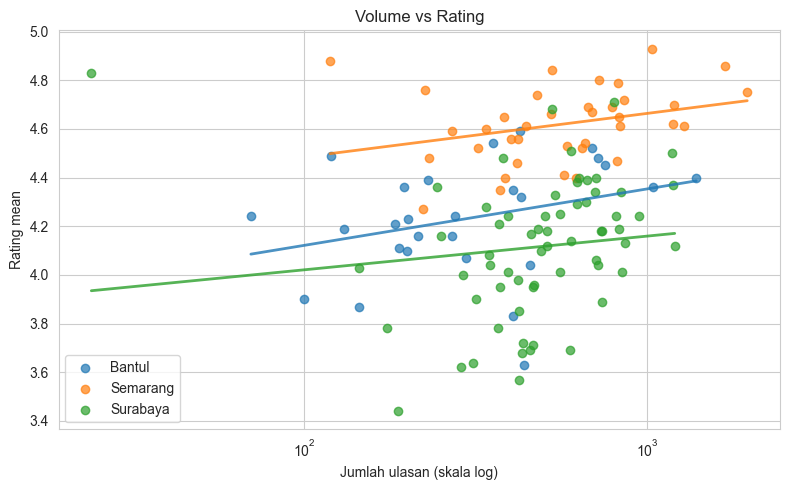

In [13]:
import numpy as np

plt.figure(figsize=(8,5))
for wil, c in zip(sorted(agg['wilayah'].unique()), ['#1f77b4','#ff7f0e','#2ca02c']):
    s = agg[agg['wilayah'] == wil]
    plt.scatter(s['n_reviews'], s['rating_mean'], label=wil, alpha=0.7, color=c)
    # garis tren OLS pada skala log-x, hanya bantu mata — bukan uji
    x = np.log10(s['n_reviews']); y = s['rating_mean']
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    plt.plot(10**xs, a + b*xs, color=c, linewidth=2, alpha=0.8)

plt.xscale('log')
plt.xlabel("Jumlah ulasan (skala log)"); plt.ylabel("Rating mean")
plt.title("Volume vs Rating")
plt.legend(); plt.tight_layout()
plt.savefig(OUT_EDA / "volume_vs_rating_per_wilayah.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Pool keluhan: ulasan negatif yang berteks bermakna
neg = df[(df['rating'].isin([1,2])) &
         (df['review_text'].notna()) &
         (df['text_length'] >= 40)].copy()
neg['t'] = neg['review_text'].str.lower()

# Tema keluhan -> dimensi SERVQUAL. Pakai \b agar tak salah-tangkap substring.
# === Kamus keyword keluhan, per dimensi SERVQUAL (Indonesia + gaul + Jawa + typo) ===
# Catatan regex: hindari \b di sekitar morfem berimbuhan; pakai akar kata + alternasi.
themes = {

  # ---------- RESPONSIVENESS (daya tanggap, kecepatan) ----------
  'Antre & waktu tunggu (Responsiveness)':
      r'antri|antre|antri+an|ngantri|ngantre|antriann?|'
      r'lama|lawas|suwe|kelamaan|kesuwen|'
      r'nunggu|menunggu|nunggu+in|ditunggu|tunggu+an|'
      r'lelet|lemot|lambat|lamban|telat|molor|ngaret|jam karet|'
      r'lama poll?|lama bgt|lama banget|berjam|jam-?jam',

  'Akses & pendaftaran (Responsiveness)':
      r'online|aplikasi|daftar|pendaftaran|antrian online|'
      r'susah daftar|ribet daftar|gak bisa daftar|error|nge-?hang|'
      r'telpon|telfon|telepon|nelpon|gak diangkat|ga diangkat|'
      r'dihubungi|kontak|wa gak|whatsapp',

  'Respons darurat / diabaikan (Responsiveness)':
      r'gawat darurat|igd|ugd|darurat|cito|'
      r'didiamkan|dibiarkan|diabaikan|gak ditangani|ga ditangani|'
      r'gak direspon|ga direspon|cuek|dicuekin|nggak digubris|gak digubris',

  # ---------- RELIABILITY (kehandalan, konsistensi, janji ditepati) ----------
  'Obat & farmasi (Reliability)':
      r'obat|resep|apotek|apotik|farmasi|'
      r'obat habis|habis obat|obat kosong|stok|stock|gak ada obat|ga ada obat|'
      r'obat generik|ditebus|nebus',

  'BPJS & administrasi (Reliability)':
      r'bpjs|kis|kartu sehat|jkn|mobile jkn|'
      r'administr|persyaratan|syarat|berkas|dokumen|'
      r'fotokopi|fotocopy|ktp|kk|kartu keluarga|'
      r'dipersulit|mempersulit|ribet|berbelit|bertele',

  'Rujukan (Reliability)':
      r'rujuk|dirujuk|surat rujukan|gak dirujuk|ga dirujuk|'
      r'minta rujukan|susah rujuk|tolak rujuk',

  'Jam operasional (Reliability)':
      r'tutup|belum buka|udah tutup|sudah tutup|jam buka|'
      r'jam tutup|jam karet|telat buka|gak buka|ga buka|libur',

  'Biaya & pungutan (Reliability)':
      r'bayar|biaya|tarif|mahal|pungli|pungutan|dimintai|'
      r'gratis tapi|kok bayar|suruh bayar',

  'Konsistensi layanan (Reliability)':
      r'beda-?beda|gak konsisten|ga konsisten|berubah|'
      r'janji|dijanji|katanya|gak sesuai|ga sesuai|tidak sesuai',

  # ---------- ASSURANCE (kompetensi, kepercayaan, keamanan) ----------
  'Kompetensi & diagnosis (Assurance)':
      r'salah diagnos|salah obat|misdiagnos|gak teliti|ga teliti|'
      r'asal|sembarangan|gak profesional|ga profesional|tidak profesional|'
      r'gak kompeten|ga kompeten|gak ahli|kurang ahli|'
      r'gak sembuh|ga sembuh|tambah parah|makin parah|tidak membaik',

  'Kepercayaan & etika (Assurance)':
      r'privasi|rahasia|dibocorkan|diobrolkan|disebarkan|'
      r'gak dipercaya|malpraktik|malpraktek|ngeyel|'
      r'maen hp|main hp|sambil hp|ngobrol sendiri|ngerumpi',

  # ---------- EMPATHY (empati, sikap, komunikasi) ----------
  'Sikap petugas negatif (Empathy)':
      r'judes|jutek|ketus|kasar|galak|sombong|cuek|nyinyir|sinis|'
      r'ngegas|bentak|ngebentak|membentak|marah|ngomel|ngomelin|'
      r'sewot|gak sopan|ga sopan|tidak sopan|nggak sopan|'
      r'gak ramah|ga ramah|tidak ramah|kurang ramah|nggak ramah|'
      r'songong|belagu|jutekin|ketusin|'
      # Jawa:
      r'\bajur|kon\b|ngenyek|ngece|ngeyel|sengak',

  'Komunikasi & informasi (Empathy)':
      r'gak jelas|ga jelas|tidak jelas|bingung|membingungkan|'
      r'gak dijelasin|ga dijelasin|gak ada penjelasan|'
      r'gak informatif|kurang informatif|gak ngasih tau|'
      r'gak diarahkan|ga diarahkan|gak dipandu',

  'Perhatian & diskriminasi (Empathy)':
      r'dibeda|dibedakan|pilih kasih|pilih-?pilih|diskrimin|'
      r'gak diperhatikan|ga diperhatikan|diremehkan|dihakimi|'
      r'gak peduli|ga peduli|tidak peduli',

  # ---------- TANGIBLES (bukti fisik) ----------
  'Kebersihan & kenyamanan (Tangibles)':
      r'kotor|jorok|bau|busuk|pesing|dekil|kumuh|'
      r'panas|gerah|sumpek|pengap|sempit|sesak|'
      r'gak nyaman|ga nyaman|tidak nyaman',

  'Fasilitas & sarana (Tangibles)':
      r'parkir|toilet|wc|kamar mandi|kursi|ruang tunggu|'
      r'rusak|bocor|mati|gak berfungsi|ga berfungsi|'
      r'ac mati|kipas|lift|tangga|akses|difabel|kursi roda|'
      r'gedung|bangunan|tempat sempit',
}

# Tandai tiap ulasan negatif per tema (boolean)
for label, pat in themes.items():
    neg[label] = neg['t'].str.contains(pat, regex=True, na=False)

# --- Tingkat 1: prevalensi global (seperti yang sudah kamu punya) ---
print('=== Prevalensi tema di seluruh ulasan negatif (bintang 1 dan 2, n={}) ==='.format(len(neg)))
glob = (neg[list(themes)].mean()*100).round(1).sort_values(ascending=False)
print(glob.to_string())

# --- Tingkat 2: sistemik? di berapa puskesmas tema ini MENONJOL ---
# Untuk tiap puskesmas, hitung % ulasan negatifnya yang menyebut tema.
# Hanya puskesmas dgn cukup ulasan negatif (>=15) agar persen stabil.
by_pkm = neg.groupby('puskesmas_id').agg(
    n_neg=('rating','count'),
    **{label: (label,'mean') for label in themes}
)
elig = by_pkm[by_pkm['n_neg'] >= 15].copy()
print(f'\n=== Sistemik check: {len(elig)} puskesmas dgn >=15 ulasan negatif ===')

THRESH = 0.30   # tema dianggap "menonjol" jika >=30% ulasan negatif puskesmas itu menyebutnya
rows = []
for label in themes:
    n_pkm = (elig[label] >= THRESH).sum()
    rows.append((label, n_pkm, round(n_pkm/len(elig)*100,1), round(elig[label].mean()*100,1)))
out = pd.DataFrame(rows, columns=['tema','n_puskesmas_menonjol',f'%_puskesmas(>={int(THRESH*100)}%)','rata2_prevalensi_%'])
out = out.sort_values('n_puskesmas_menonjol', ascending=False)
print(out.to_string(index=False))

=== Prevalensi tema di seluruh ulasan negatif (bintang 1 dan 2, n=7912) ===
Antre & waktu tunggu (Responsiveness)           43.5
Sikap petugas negatif (Empathy)                 31.9
Obat & farmasi (Reliability)                    18.7
BPJS & administrasi (Reliability)               18.0
Akses & pendaftaran (Responsiveness)            17.1
Konsistensi layanan (Reliability)                9.7
Fasilitas & sarana (Tangibles)                   9.5
Rujukan (Reliability)                            8.8
Biaya & pungutan (Reliability)                   8.5
Kompetensi & diagnosis (Assurance)               5.8
Jam operasional (Reliability)                    5.2
Komunikasi & informasi (Empathy)                 4.8
Kebersihan & kenyamanan (Tangibles)              4.1
Respons darurat / diabaikan (Responsiveness)     3.8
Kepercayaan & etika (Assurance)                  1.6
Perhatian & diskriminasi (Empathy)               0.6

=== Sistemik check: 120 puskesmas dgn >=15 ulasan negatif ===
             